## Imports

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import os
import sys
sys.path.append('../Drafts')
from processing_module import round_hours

## Loading DOT Data

In [37]:
dot_prices  = pd.read_parquet('../Crypto_QTS_Data_Processed/dot_price_processed.parquet')
dot_staking = pd.read_parquet('../data/on_chain_data/processed/dot_staking_data.parquet')
dot_tech    = pd.read_parquet('../data/data_segmented_tech/dot_data.parquet')

dot_staking.index = pd.to_datetime(dot_staking.index)

dot_prices.index = pd.to_datetime(dot_prices.index)

dot_tech['time_close'] = pd.to_datetime(dot_tech['time_close'])
dot_tech['time_close'] = dot_tech['time_close'].dt.round('min')
dot_tech.set_index('time_close', inplace=True)

dot_features = dot_staking.copy()

global_start = max(dot_features.index.min(), dot_prices.index.min(), dot_tech.index.min())
global_end   = min(dot_features.index.max(), dot_prices.index.max(), dot_tech.index.max())

dot_features_aligned = dot_features.loc[global_start:global_end]
dot_prices_aligned   = dot_prices.loc[global_start:global_end]

dot_tech_aligned = dot_tech.loc[global_start:global_end].copy()

dot_prices_aligned = dot_prices_aligned[~dot_prices_aligned.index.duplicated(keep='first')]
dot_tech_aligned   = dot_tech_aligned[~dot_tech_aligned.index.duplicated(keep='first')]

dot_tech_aligned = dot_tech_aligned.reindex(dot_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
dot_tech_selected = dot_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

data = dot_features_aligned.join(
    dot_prices_aligned[['price_close']], 
    how='inner'
)

data = data.join(dot_tech_selected, how='left')

lag_cols = [ 
    'real_reward_rate',
    'staked_tokens', 'staking_ratio','active_validators'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [38]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

In [40]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.9 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 73.75%
Test accuracy: 88.78%


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


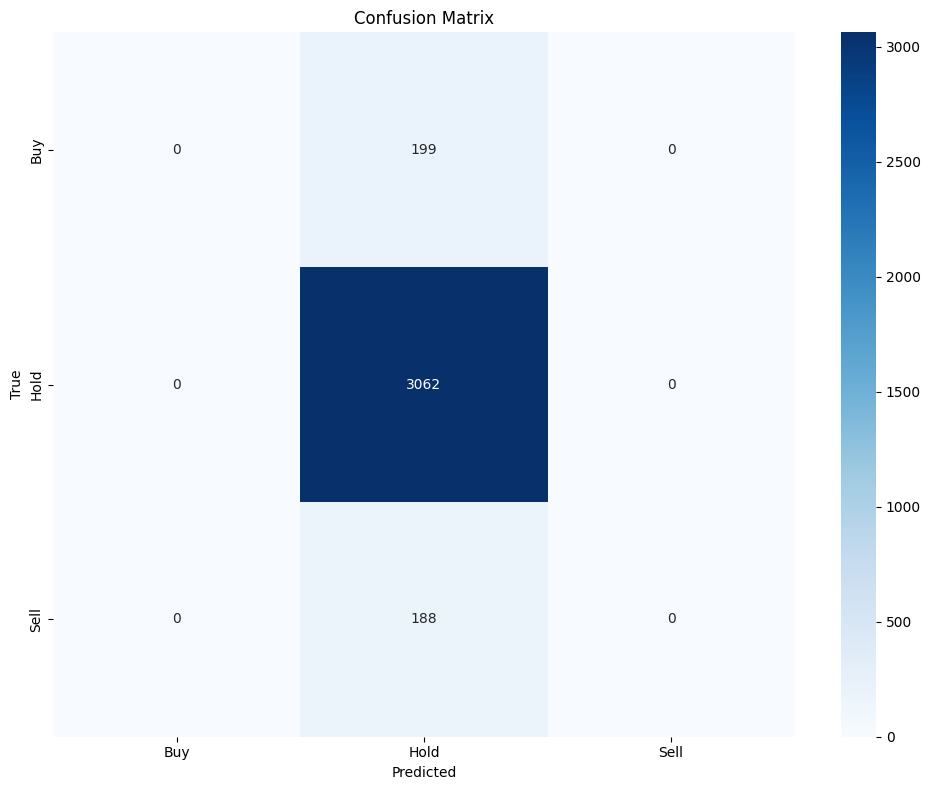


Classification Report:
              precision    recall  f1-score   support

         Buy       0.00      0.00      0.00       199
        Hold       0.89      1.00      0.94      3062
        Sell       0.00      0.00      0.00       188

    accuracy                           0.89      3449
   macro avg       0.30      0.33      0.31      3449
weighted avg       0.79      0.89      0.84      3449



c:\Users\matth\AnacondaDist\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\matth\AnacondaDist\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\matth\AnacondaDist\envs\py312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

In [41]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

True \ Predicted
Buy
Hold
Sell
Buy (Actual)
38 (correct)
439 (wrong)
12 (wrong)
Hold (Actual)
216 (wrong)
8851 (correct)
69 (wrong)
Sell (Actual)
37 (wrong)
449 (wrong)
17 (correct


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Trading Performance on Test Data:
Total PnL (percentage): 0.03%
Absolute PnL: $34.20
Annualized Sharpe Ratio: 0.0114


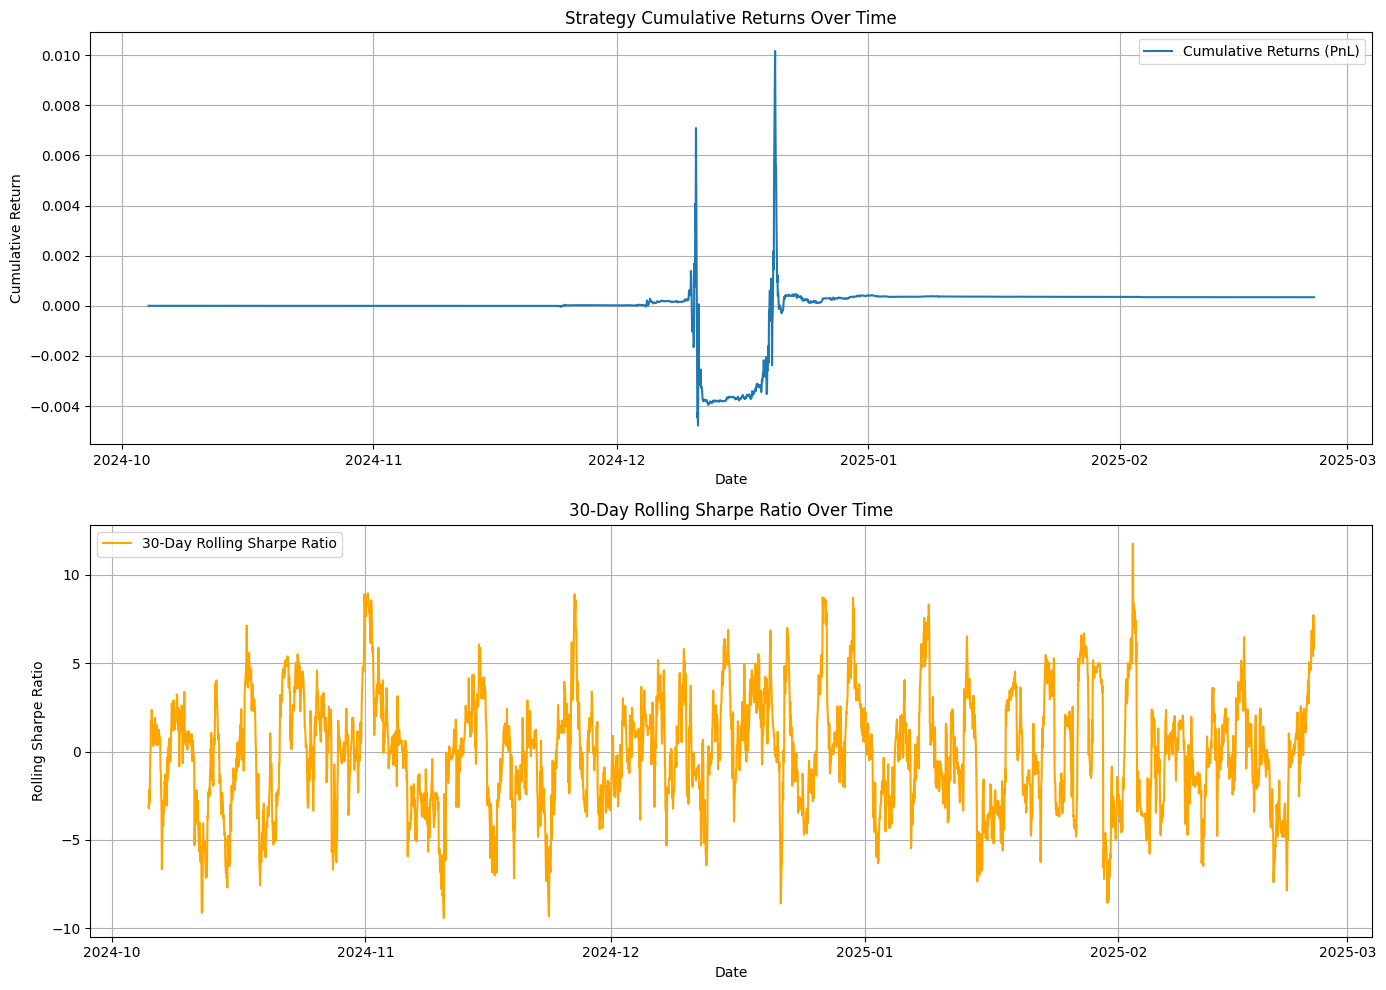

In [51]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(365)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [53]:
def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan
    
    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan
    
    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

performance_metrics = compute_performance_metrics(returns_series, freq_per_year=365, alpha=0.05)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")

Performance Metrics:
mean_return_annual: 4.791264655068517e-05
vol_annual: 0.004197621982647954
sharpe_ratio: 0.011414235666943214
max_drawdown: -0.011779848486185074
calmar_ratio: 0.004067339934408665
VaR_95: 1.1292722183497972e-05
CVaR_95: 0.00027109315851703286


In [43]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))



Training run 1/10
Train accuracy: 77.92%
Test accuracy: 5.89%
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Run 1 Trading Performance:
  Total PnL (percentage): -37.07%
  Absolute PnL: $-37,072.79
  Annualized Sharpe Ratio: -0.1995

Training run 2/10
Train accuracy: 78.00%
Test accuracy: 5.77%
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Run 2 Trading Performance:
  Total PnL (percentage): 10.20%
  Absolute PnL: $10,204.28
  Annualized Sharpe Ratio: 0.1577

Training run 3/10
Train accuracy: 71.66%
Test accuracy: 5.45%
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Run 3 Trading Performance:
  Total PnL (percentage): -44.82%
  Absolute PnL: $-44,821.91
  Annualized Sharpe Ratio: -0.1661

Training run 4/10
Train accuracy: 74.10%
Test accuracy: 5.45%
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Run 4 Trading Performance:
  Total PnL (percentage): -43.00%
  Absolute PnL: $-43,002.81
  Annualized Sharpe Ratio: -0.1580

Training run 5/10
Train accuracy: 79.61%
Test accuracy: 88.63%
108/108 ━━━━━━━━━━━━━━━━━

In [49]:
def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan
    
    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan
    
    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

performance_metrics = compute_performance_metrics(returns_series, freq_per_year=8760, alpha=0.05)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")

Performance Metrics:
mean_return_annual: 0.0027404858265072107
vol_annual: 0.004598152072271129
sharpe_ratio: 0.5959972144100106
max_drawdown: -0.002633943920955062
calmar_ratio: 1.040449619293213
VaR_95: 5.284021244733593e-06
CVaR_95: 7.417409506160766e-05
